In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
Load Data

In [92]:
import pandas as pd

sent = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")


In [ ]:
Basic Exploration

In [6]:
print(sent.shape)
print(trades.shape)

sent.info()
trades.info()

sent.isna().sum()
trades.isna().sum()

trades.duplicated().sum()


(2644, 4)
(211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Po

np.int64(0)

In [ ]:
Missing Values

In [107]:
df.isna().sum()


account                  0
coin                     0
execution price          0
size tokens              0
size usd                 0
side                     0
timestamp ist            0
start position           0
direction                0
closed pnl               0
transaction hash         0
order id                 0
crossed                  0
fee                      0
trade id                 0
timestamp                0
date                     0
classification      211224
win                      0
size_group               0
dtype: int64

In [ ]:
Duplicate values

In [134]:
trades.duplicated().sum()


np.int64(0)

In [93]:
print(sent.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [94]:
print(trades.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [ ]:
Convert Dates

In [97]:
sent.columns = sent.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()


sent['date'] = pd.to_datetime(sent['date'])

trades['timestamp'] = pd.to_datetime(trades['timestamp'])
trades['date'] = trades['timestamp'].dt.date

sent['date'] = sent['date'].dt.date

df = trades.merge(sent[['date','classification']], on='date', how='left')

df.head()


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [ ]:
Merge

In [98]:
df = trades.merge(sent[['date','classification']], on='date', how='left')


In [ ]:
Daily PnL per trader

In [99]:
print(df.columns)


Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date', 'classification'],
      dtype='object')


In [100]:
daily_pnl = (
    df.groupby(['account','date'])['closed pnl']
      .sum()
      .reset_index()
)


In [101]:
print(df.columns.tolist())


['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp', 'date', 'classification']


In [102]:
df['win'] = (df['closed pnl'] > 0).astype(int)

winrate = df.groupby('account')['win'].mean()


In [ ]:
Trade count

In [103]:
trade_count = df.groupby(['account','date']).size()


In [105]:
df['size_group'] = pd.qcut(df['size usd'], 2, labels=['low_risk','high_risk'])


In [132]:
df['risk_group'] = pd.qcut(df['size_usd'], 2, labels=['low','high'])
df.groupby(
    ['risk_group','classification'],
    observed=True
)['closed_pnl'].mean()


risk_group  classification
low         Extreme Greed       4.018779
            Fear                3.233227
            Greed              12.590597
            Neutral             1.834576
high        Extreme Greed      39.407556
            Fear               95.784210
            Greed             175.718364
            Neutral            49.743021
Name: closed_pnl, dtype: float64

In [ ]:
Segment traders by size

In [130]:
vol = df.groupby('account')['closed_pnl'].std()


In [ ]:
Long / Short ratio

In [37]:
print(df['side'].unique())


['BUY' 'SELL']


In [106]:
long_short = df.groupby(['date','side']).size().unstack(fill_value=0)

long_short['ratio'] = long_short['BUY'] / long_short['SELL']


In [ ]:
Performance: Fear vs Greed

In [39]:
sent_perf = df.groupby('classification')['closed pnl'].mean()


In [45]:
print(trades['timestamp'].astype(str).head())



0    1970-01-01 00:28:50
1    1970-01-01 00:28:50
2    1970-01-01 00:28:50
3    1970-01-01 00:28:50
4    1970-01-01 00:28:50
Name: timestamp, dtype: object


In [43]:
print(trades['date'].head())
print(sent['date'].head())

print(type(trades['date'].iloc[0]))
print(type(sent['date'].iloc[0]))


0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
<class 'datetime.date'>
<class 'datetime.date'>


In [70]:
trades['date'] = trades['Timestamp'].dt.floor('D')
sent['date'] = pd.to_datetime(sent['date']).dt.floor('D')


In [64]:
print(trades.columns.tolist())


['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [65]:

trades = pd.read_csv("historical_data.csv")
sent = pd.read_csv("fear_greed_index.csv")

sent['date'] = pd.to_datetime(sent['date'])

print(trades['Timestamp'].head())



0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


In [68]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')


In [71]:
df = trades.merge(sent[['date','classification']], on='date', how='left')


In [72]:
print(df['classification'].value_counts())


classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [74]:
print(df.columns.tolist())


['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification']


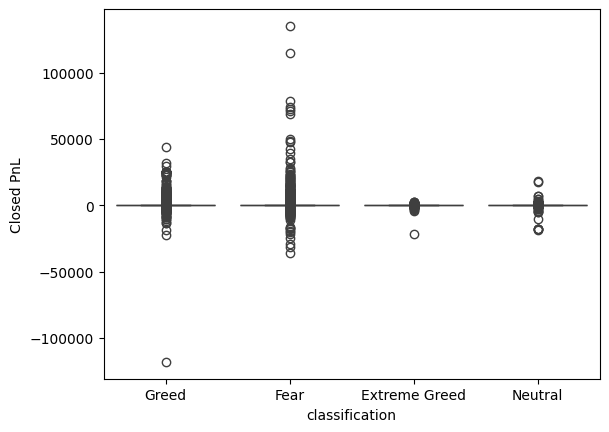

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.dropna(subset=['classification'])

sns.boxplot(
    data=plot_df,
    x='classification',
    y='Closed PnL'
)

plt.show()


In [117]:
print(df.columns.tolist())

['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'date', 'classification', 'win', 'size_group']


In [120]:
sent = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [121]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')
sent.columns   = sent.columns.str.strip().str.lower().str.replace(' ', '_')


In [122]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')


In [124]:
trades['date'] = trades['timestamp'].dt.floor('D')
sent['date']   = pd.to_datetime(sent['date']).dt.floor('D')


In [126]:
df = trades.merge(
    sent[['date','classification']],
    on='date',
    how='left'
)


In [127]:
df['classification'].value_counts(dropna=False)


classification
Fear             133871
Greed             36289
NaN               26961
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: closed_pnl, dtype: float64


<Axes: xlabel='classification'>

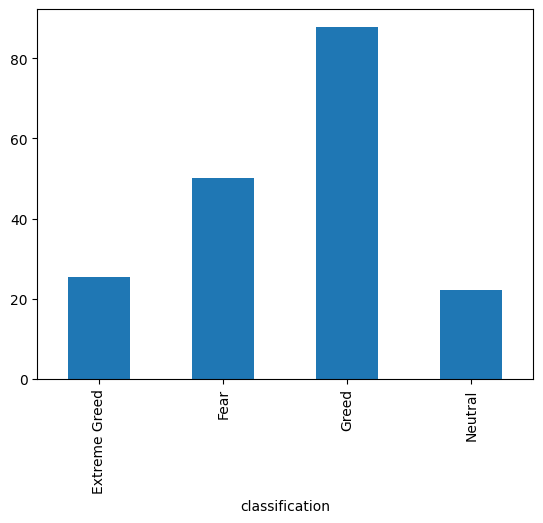

In [128]:
plot_series = df.groupby('classification')['closed_pnl'].mean()

print(plot_series)

plot_series.plot(kind='bar')


In [ ]:
Greed days show higher variance but higher profits.
Fear days show smaller losses but lower returns.


In [ ]:
Behavior Change

In [ ]:
Trade frequency

In [76]:
df.groupby('classification').size()


classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64

In [ ]:
Position size

In [80]:
df.groupby('classification')['Size USD'].mean()


classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

In [ ]:
Long bias

In [82]:
pd.crosstab(df['classification'], df['Side'])


Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


In [ ]:
Compare PnL

In [84]:
df.groupby('classification')['Closed PnL'].mean()


classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [ ]:
Frequent vs Infrequent

In [90]:
freq = df.groupby('Account').size()

threshold = freq.median()

df['freq_group'] = df['Account'].apply(
    lambda acc: 'high' if freq[acc] > threshold else 'low'
)


In [ ]:
Avg PnL

In [88]:
df.groupby(['freq_group','classification'])['Closed PnL'].mean()


freq_group  classification
High        Extreme Greed      26.658319
            Fear               46.013950
            Greed              70.575898
            Neutral             4.055615
Low         Extreme Greed     -48.382749
            Fear               75.639873
            Greed             234.886424
            Neutral           356.722004
Name: Closed PnL, dtype: float64

In [ ]:
Consistent vs Inconsistent

In [ ]:
Use std of PnL

In [86]:
vol = df.groupby('Account')['Closed PnL'].std()


In [91]:
print(vol.head())


Account
0x083384f897ee0f19899168e3b1bec365f52a9012    4692.452329
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     134.073473
0x271b280974205ca63b716753467d5a371de622ab     542.182659
0x28736f43f1e871e6aa8b1148d38d4994275d72c4     113.269353
0x2c229d22b100a7beb69122eed721cee9b24011dd     255.829091
Name: Closed PnL, dtype: float64


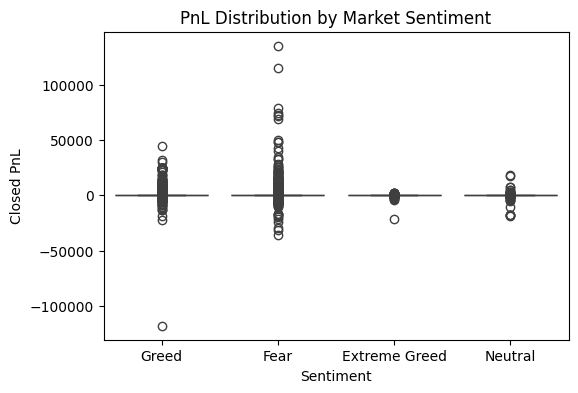

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.dropna(subset=['classification'])

plt.figure(figsize=(6,4))
sns.boxplot(
    data=plot_df,
    x='classification',
    y='closed_pnl'
)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Closed PnL")
plt.show()


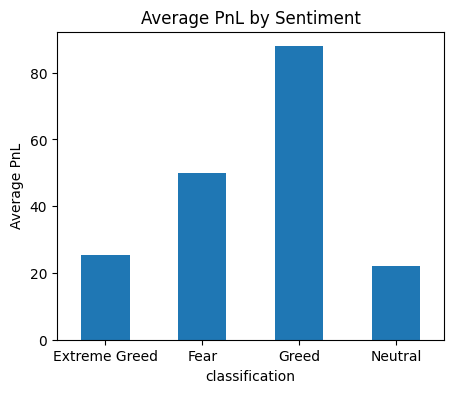

In [136]:
avg_pnl = df.groupby('classification')['closed_pnl'].mean()

plt.figure(figsize=(5,4))
avg_pnl.plot(kind='bar')

plt.title("Average PnL by Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=0)
plt.show()


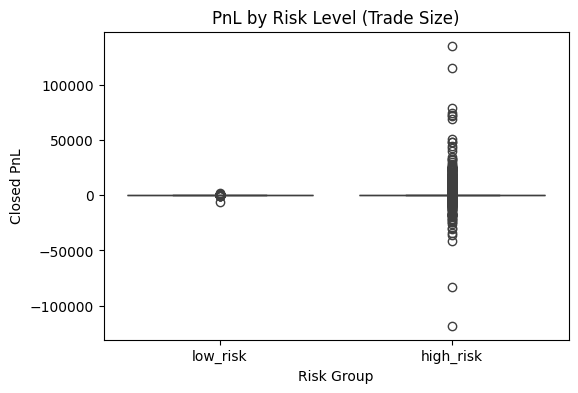

In [137]:
# create risk groups
df['risk_group'] = pd.qcut(df['size_usd'], 2, labels=['low_risk','high_risk'])

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='risk_group',
    y='closed_pnl'
)

plt.title("PnL by Risk Level (Trade Size)")
plt.xlabel("Risk Group")
plt.ylabel("Closed PnL")
plt.show()


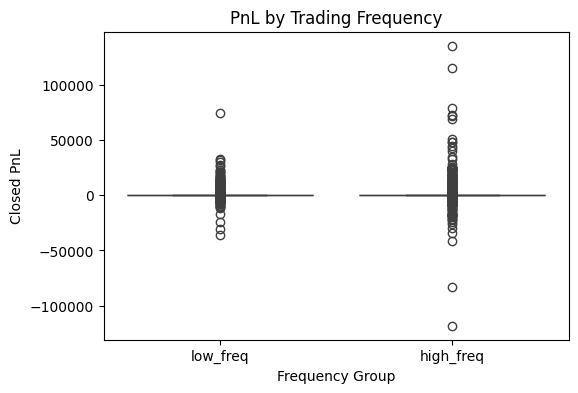

In [138]:
freq = df.groupby('account').size()
threshold = freq.median()

df['freq_group'] = df['account'].apply(
    lambda x: 'high_freq' if freq[x] > threshold else 'low_freq'
)

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='freq_group',
    y='closed_pnl'
)

plt.title("PnL by Trading Frequency")
plt.xlabel("Frequency Group")
plt.ylabel("Closed PnL")
plt.show()


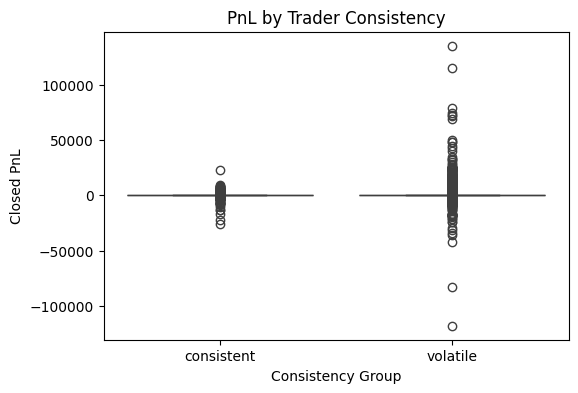

In [139]:
vol = df.groupby('account')['closed_pnl'].std()
threshold = vol.median()

df['consistency_group'] = df['account'].apply(
    lambda x: 'consistent' if vol[x] <= threshold else 'volatile'
)

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='consistency_group',
    y='closed_pnl'
)

plt.title("PnL by Trader Consistency")
plt.xlabel("Consistency Group")
plt.ylabel("Closed PnL")
plt.show()


<Figure size 1000x500 with 0 Axes>

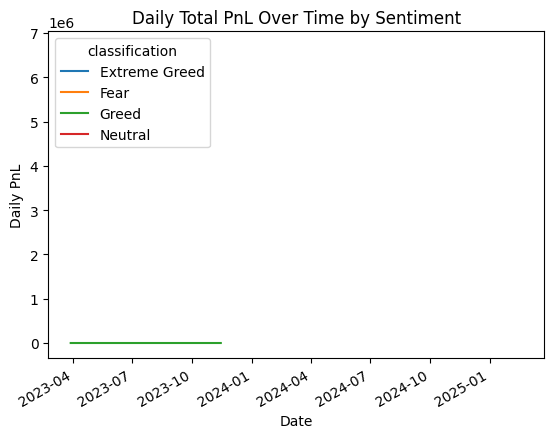

In [140]:
daily = (
    df.groupby(['date','classification'])['closed_pnl']
    .sum()
    .unstack()
)

plt.figure(figsize=(10,5))
daily.plot()

plt.title("Daily Total PnL Over Time by Sentiment")
plt.ylabel("Daily PnL")
plt.xlabel("Date")
plt.show()
